In [1]:
from IPython.display import display, Image
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt

# Creating a basic sequential graph

In [2]:
class State(TypedDict):
    nlist: List[str]

In [3]:
def node_a(state: State) -> State:
    print(f"node a is receiving {state['nlist']}")
    note = "Hello World from Node a"
    return State(nlist=[note])

In [4]:
builder = StateGraph(State)
builder.add_node("a", node_a)
builder.add_edge(START, "a")
builder.add_edge("a", END)

graph = builder.compile()

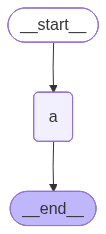

In [5]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
initial_state = State(nlist=["Hello node a, how are you?"])
graph.invoke(initial_state)

node a is receiving ['Hello node a, how are you?']


{'nlist': ['Hello World from Node a']}

# Creating a parallel Execution Graph

In [7]:
# Create a basic State for graph
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]
    tracker: Annotated[int, operator.add]

In [8]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']} with tracker value {state['tracker']}")
    note = "A"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']} with tracker value {state['tracker']}")
    note = "B"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']} with tracker value {state['tracker']}")
    note = "C"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']} with tracker value {state['tracker']}")
    note = "BB"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']} with tracker value {state['tracker']}")
    note = "CC"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']} with tracker value {state['tracker']}")
    note = "D"
    tracked = 1
    return State(nlist=[note],tracker=tracked)

In [9]:
builder = StateGraph(State)

builder.add_node("A", node_a)
builder.add_node("B", node_b)
builder.add_node("C", node_c)
builder.add_node("BB", node_bb)
builder.add_node("CC", node_cc)
builder.add_node("D", node_d)

builder.add_edge(START, "A")
builder.add_edge("A", "B")
builder.add_edge("A", "C")
builder.add_edge("B", "BB")
builder.add_edge("C", "CC")
builder.add_edge("BB", END)
builder.add_edge("CC", END)
builder.add_edge("A", "D")
builder.add_edge("D", END)

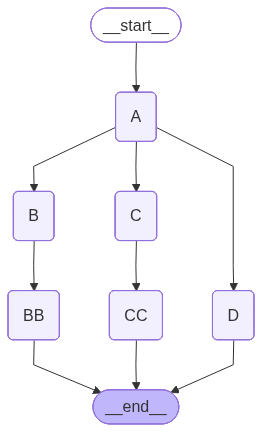

In [10]:
graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
initial_state = State(nlist=["Initial String"],tracker=0)
graph.invoke(initial_state)

Adding 'A' to ['Initial String'] with tracker value 0
Adding 'B' to ['Initial String', 'A'] with tracker value 1
Adding 'C' to ['Initial String', 'A'] with tracker value 1
Adding 'D' to ['Initial String', 'A'] with tracker value 1
Adding 'BB' to ['Initial String', 'A', 'B', 'C', 'D'] with tracker value 4
Adding 'CC' to ['Initial String', 'A', 'B', 'C', 'D'] with tracker value 4


{'nlist': ['Initial String', 'A', 'B', 'C', 'D', 'BB', 'CC'], 'tracker': 6}

# Condidtional Edges

In [ ]:
class State(TypedDict):
    nlist: Annotated[List[str], operator.add]

In [ ]:
def node_a(state: State) -> Command[Literal["B","C",END]]: 
    
    select = state["nlist"][-1]

    if select == "B":
        next_node = "B"
    if select == "C":
        next_node = "C"
    elif select == "Q":
        next_node = END
    else:
        next_node = END

    return Command(
        update=State(nlist=[select]),
        goto=[next_node]
    )

def node_b(state: State):
    return(State(nlist=["Node B"]))

def node_c(state: State):
    return(State(nlist=["Node C"]))

def conditional_edge(state: State) -> Literal["B","C",END]:
    select = state["nlist"][-1]
    if select == "B":
        return "B"
    if select == "C":
        return "C"
    elif select == "Q":
        return END
    else:
        return END

builder = StateGraph(State)

builder.add_node("A", node_a)
builder.add_node("B", node_b)
builder.add_node("C", node_c)

builder.add_edge(START, "A")
builder.add_edge("B", END)
builder.add_edge("C", END)
# builder.add_conditional_edges("A", conditional_edge)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
user = input("Enter a node to go to")

input_state = State(nlist=[user])
graph.invoke(input_state)

{'nlist': ['B', 'B']}

# Memory Checkpoints

In [38]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {"configurable":{"thread_id":"1"}}

graph = builder.compile(checkpointer=memory)

In [41]:
while True:
    user = input("Select a node, or press Q to quit")
    print(f"User selected {user}")

    input_state = State(nlist=[user])
    result = graph.invoke(input_state, config)

    print(result)

    if result["nlist"][-1] == "Q":
        print("quit")
        break

User selected B
{'nlist': ['B', 'B']}
User selected q
{'nlist': ['B', 'B', 'q', 'q']}
User selected Q
{'nlist': ['B', 'B', 'q', 'q', 'Q', 'Q']}
quit


# HITL

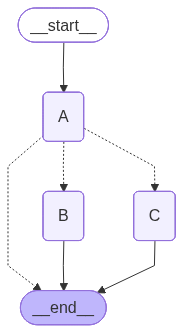

In [46]:
def node_a(state: State) -> Command[Literal["B","C",END]]: 
    print('Entered A node')

    select = state["nlist"][-1]

    if select == "B":
        next_node = "B"
    if select == "C":
        next_node = "C"
    elif select == "Q":
        next_node = END
    else: #illegal value
        admin = interrupt(f"Unexpected value {select} received at node A")
        print(admin)

        if admin == "continue":
            next_node = "B"
        else:
            next_node = END
            select = "Q"

    return Command(
        update=State(nlist=[select]),
        goto=[next_node]
    )

def node_b(state: State):
    return(State(nlist=["Node B"]))

def node_c(state: State):
    return(State(nlist=["Node C"]))

def conditional_edge(state: State) -> Literal["B","C",END]:
    select = state["nlist"][-1]
    if select == "B":
        return "B"
    if select == "C":
        return "C"
    elif select == "Q":
        return END
    else:
        return END

builder = StateGraph(State)

builder.add_node("A", node_a)
builder.add_node("B", node_b)
builder.add_node("C", node_c)

builder.add_edge(START, "A")
builder.add_edge("B", END)
builder.add_edge("C", END)
# builder.add_conditional_edges("A", conditional_edge)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {"configurable":{"thread_id":"1"}}

graph = builder.compile(checkpointer=memory)

In [49]:
while True:
    user = input("Select a node, or press Q to quit")
    print(f"User selected {user}")

    input_state = State(nlist=[user])
    result = graph.invoke(input_state, config)

    print(result)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)

        human = input(f"\n{msg}:")

        human_response = Command(
            resume = human
        )

        result = graph.invoke(human_response, config)

    if result["nlist"][-1] == "Q":
        print("quit")
        break

User selected p
Entered A node
{'nlist': ['B', 'B', 'Q', 'p'], '__interrupt__': [Interrupt(value='Unexpected value p received at node A', id='0b48733adf66d2298e0f988cb17028fc')]}
Interrupt:{'nlist': ['B', 'B', 'Q', 'p'], '__interrupt__': [Interrupt(value='Unexpected value p received at node A', id='0b48733adf66d2298e0f988cb17028fc')]}
Unexpected value p received at node A
Entered A node
continue
User selected B
Entered A node
{'nlist': ['B', 'B', 'Q', 'p', 'p', 'Node B', 'B'], '__interrupt__': [Interrupt(value='Unexpected value B received at node A', id='83847a3331b055fad57705457fa733d9')]}
Interrupt:{'nlist': ['B', 'B', 'Q', 'p', 'p', 'Node B', 'B'], '__interrupt__': [Interrupt(value='Unexpected value B received at node A', id='83847a3331b055fad57705457fa733d9')]}
Unexpected value B received at node A
Entered A node
quit
quit
